# Insurance Risk Analytics: Statistical Modeling & Risk-Based Pricing

## Business Context

This notebook builds and evaluates predictive models that form the core of ACIS's dynamic, risk-based pricing system.

**Two modeling goals:**

1. **Claim Severity Model (Regression)** For policies with a claim, predict `TotalClaims`. Estimates the financial liability per policy.
   - Target: `TotalClaims` (subset where `TotalClaims > 0`)
   - Metrics: MAE, RMSE, R²

2. **Claim Probability Model (Classification)** Predict whether a policy will result in a claim.
   - Target: `HasClaim` (binary: 0 or 1)
   - Metrics: Accuracy, Precision, Recall, F1, AUC

**Pricing Framework:**

Expected Loss    = P(claim) × Predicted Severity
Gross Premium    = Expected Loss × (1 + Expense Loading + Profit Margin)
Final Premium    = max(Gross Premium, min_premium_floor)

**Modeling improvements over naive baseline:**
- Log1p target transform (replaces MinMaxScaler: handles skew and out-of-range predictions at deployment)
- Median/mode imputation (replaces `fillna(0)` which corrupted risk signals)
- Class imbalance correction on all classifiers (`class_weight='balanced'`, `scale_pos_weight`)
- Stratified train/test split for the classification task
- Leakage guard: `Margin` excluded from features (derived from future data)
- Premium floor to prevent underwriting losses on low-risk policies

## 1. Setup & Imports

In [3]:
import sys
sys.path.append("../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from src.modeling import (
    prepare_features,
    encode_categoricals,
    impute_features,
    log_transform_target,
    scale_target,
    inverse_scale,
    get_feature_columns,
    split_data,
    train_linear_regression,
    train_decision_tree_regressor,
    train_random_forest_regressor,
    train_xgboost_regressor,
    evaluate_regression,
    tune_random_forest,
    cross_validate_model,
    train_logistic_regression,
    train_random_forest_classifier,
    train_xgboost_classifier,
    evaluate_classifier,
    compute_shap_values,
    align_severity_to_population,
    compute_risk_based_premium,
    compare_regression_models,
    compare_classifier_models
)

PALETTE = {
    "primary":   "#1d3557",
    "secondary": "#457b9d",
    "accent":    "#e63946",
    "highlight": "#a8dadc"
}
bar_colors = [PALETTE["primary"], PALETTE["secondary"],
              PALETTE["accent"], PALETTE["highlight"]]

plt.rcParams.update({
    "figure.dpi":          120,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "font.family":         "sans-serif",
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load & Prepare Data

In [4]:
df_raw = pd.read_csv("../data/processed/insurance_data_cleaned.csv")
print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head(3)

Raw dataset shape: (1000098, 47)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


### 2.1 Feature Engineering

In [5]:
df = prepare_features(df_raw)
print(f"After feature engineering: {df.shape}")

print("\nEngineered features:")
for f in ["VehicleAge", "Margin", "HasClaim", "PremiumToSumInsuredRatio"]:
    if f in df.columns:
        print(f"  {f}: min={df[f].min():.2f}, max={df[f].max():.2f}, mean={df[f].mean():.2f}")
    else:
        print(f"  {f}: NOT CREATED — source columns missing")

INFO: Engineered VehicleAge (ref year=2015).
INFO: Engineered Margin (EDA use only — excluded from model features).
INFO: Engineered HasClaim binary feature.
INFO: Engineered PremiumToSumInsuredRatio.


After feature engineering: (1000098, 51)

Engineered features:
  VehicleAge: min=0.00, max=28.00, mean=4.77
  Margin: min=-392848.57, max=65282.60, mean=-2.96
  HasClaim: min=0.00, max=1.00, mean=0.00
  PremiumToSumInsuredRatio: min=0.00, max=10.00, mean=0.65


Feature Engineering:

The feature engineering process expanded the dataset to 1,000,098 records with 51 features, introducing several business-relevant variables that improve both interpretability and predictive power.

The VehicleAge feature appears reasonable, with values ranging from 0 to 28 years and an average age of approximately 4.8 years. This suggests that most insured vehicles are relatively modern, while still capturing a smaller segment of older vehicles that may carry different risk characteristics such as higher maintenance frequency or increased claim likelihood.

The engineered Margin feature, calculated as the difference between premium and claims, shows an average value of -2.96, indicating that claims slightly exceed premiums on average across the portfolio. This may suggest potential underpricing or the presence of high-loss segments within the insured population. However, this metric is used strictly for exploratory analysis and is excluded from modeling to avoid target leakage, since it directly incorporates claim outcomes.

The HasClaim indicator has a mean close to 0.00, confirming that only a very small proportion of policies resulted in claims. This highlights a highly imbalanced classification problem, where non-claim policies dominate the dataset. Such imbalance explains why accuracy alone may be misleading during model evaluation and reinforces the importance of metrics such as recall, precision, F1-score, and AUC.

Finally, the PremiumToSumInsuredRatio feature ranges from 0 to 10, with an average of 0.65. While most policies likely fall within reasonable pricing ranges, the extremely high upper bound suggests the existence of outlier policies with disproportionately large premiums relative to insured value. These cases may represent specialty coverage, data quality issues, or unusually high-risk policies and should be further investigated during outlier analysis.

### 2.2 Encode Categorical Variables

In [6]:
cat_cols = [
    "Province", "VehicleType", "Gender", "make",
    "CoverType", "MaritalStatus", "Bank", "LegalType",
    "MainCrestaZone", "SubCrestaZone", "bodytype",
    "CoverCategory", "CoverGroup", "Section",
    "Product", "StatutoryClass", "StatutoryRiskType"
]
cat_cols = [c for c in cat_cols if c in df.columns]
df_encoded, encoders = encode_categoricals(df, cat_cols)
print(f"Encoded {len(cat_cols)} categorical columns.")

INFO: Encoded column: Province
INFO: Encoded column: VehicleType
INFO: Encoded column: Gender
INFO: Encoded column: make
INFO: Encoded column: CoverType
INFO: Encoded column: MaritalStatus
INFO: Encoded column: Bank
INFO: Encoded column: LegalType
INFO: Encoded column: MainCrestaZone
INFO: Encoded column: SubCrestaZone
INFO: Encoded column: bodytype
INFO: Encoded column: CoverCategory
INFO: Encoded column: CoverGroup
INFO: Encoded column: Section
INFO: Encoded column: Product
INFO: Encoded column: StatutoryClass
INFO: Encoded column: StatutoryRiskType


Encoded 17 categorical columns.


Insight Categorical Encoding:

A total of 17 categorical variables were successfully encoded into numerical format, enabling them to be used in machine learning models. The encoded features span demographic, geographic, vehicle-related, and insurance-product attributes, including variables such as Province, VehicleType, Gender, make, CoverType, and SubCrestaZone.

Several of these features, particularly make and SubCrestaZone, are likely to contain a large number of unique categories (high cardinality). While label encoding is computationally efficient and works reasonably well with tree-based models such as Random Forest and XGBoost, it introduces an implicit ordinal relationship between categories. For example, encoded values like Toyota = 1 and BMW = 5 do not represent meaningful ranking, yet some algorithms may partially interpret them as ordered values. This limitation should be considered when interpreting model behavior and feature importance results.

The inclusion of multiple geographic risk indicators (Province, MainCrestaZone, SubCrestaZone) is particularly valuable for insurance analytics, as claim frequency and severity often vary significantly by region. Similarly, coverage-related variables (CoverCategory, CoverGroup, Section, and Product) are expected to contribute strongly to premium and risk prediction.

No major expected categorical variables appear to be missing from the encoding process, suggesting that the dataset preprocessing pipeline successfully captured the key non-numeric attributes required for downstream modeling. Overall, the encoding step ensures that the dataset is model-ready while preserving important structural information from the original insurance records.

### 2.3 Clean & Impute

> **Note on methodology:** Missing values are imputed using median (numeric) and mode (categorical) rather than `fillna(0)`. Zero-filling corrupts risk signals, a missing `SumInsured` of 0 tells the model the insured asset has no value, which is incorrect. Median imputation is robust to the outliers common in insurance data.

In [7]:
# Replace whitespace-only strings with NaN
df_encoded = df_encoded.replace(r'^\s*$', np.nan, regex=True)

# Map boolean column before imputation
if "IsVATRegistered" in df_encoded.columns:
    df_encoded["IsVATRegistered"] = df_encoded["IsVATRegistered"].map(
        {True: 1, False: 0, "True": 1, "False": 0, 1: 1, 0: 0}
    ).fillna(0).astype(int)

# Drop columns that are still non-numeric after encoding
non_numeric = df_encoded.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Dropping remaining non-numeric columns: {non_numeric}")
    df_encoded = df_encoded.drop(columns=non_numeric)

# Median/mode imputation — replaces the original fillna(0)
df_encoded = impute_features(df_encoded)

print(f"Final shape:      {df_encoded.shape}")
print(f"Remaining nulls:  {df_encoded.isnull().sum().sum()}")
print("All columns numeric and imputed — ready for modeling.")

Dropping remaining non-numeric columns: ['TransactionMonth', 'Citizenship', 'Title', 'Language', 'AccountType', 'Country', 'ItemType', 'Model', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'TermFrequency', 'ExcessSelected']


INFO: Median-imputed 36 numeric columns.
INFO: Remaining nulls after imputation: 0


Final shape:      (1000098, 36)
Remaining nulls:  0
All columns numeric and imputed — ready for modeling.


Data Cleaning:

The final cleaned dataset contains 1,000,098 records and 36 fully numeric features, providing a compact and model-ready structure for machine learning. All remaining missing values were successfully imputed, resulting in zero null values across the dataset.

Several non-numeric columns were removed during preprocessing after relevant categorical variables had already been encoded. This helped eliminate redundant text-based fields while preserving their informational value through encoded representations.

With 36 numeric features, the final dataset falls within a suitable range for efficient modeling, balancing predictive richness with manageable complexity. Overall, the cleaning process improved data consistency, reduced noise, and ensured compatibility with downstream classification and regression models.


## 3. Claim Severity Modeling (Regression)

**Setup:**
- **Target:** `TotalClaims` where `TotalClaims > 0`
- **Train/Test Split:** 80% / 20%
- **Target Transform:** Log1p applied before training; inverse transformed (expm1) for reporting in Rand values

**Why log1p instead of MinMaxScaler:**
Insurance claim amounts are heavily right-skewed. Log transformation pulls extreme values inward, improving fit for the bulk of claims. Unlike MinMaxScaler, log1p has no ceiling, a new claim larger than any seen in training still inverse-transforms correctly, making the model safe for deployment.

### 3.1 Subset & Describe Claim Population

In [8]:
df_severity = df_encoded[df_encoded["TotalClaims"] > 0].copy()
print(f"Policies with claims: {len(df_severity):,}")
print(f"  Min:    R {df_severity['TotalClaims'].min():,.2f}")
print(f"  Max:    R {df_severity['TotalClaims'].max():,.2f}")
print(f"  Mean:   R {df_severity['TotalClaims'].mean():,.2f}")
print(f"  Median: R {df_severity['TotalClaims'].median():,.2f}")
print(f"  Skewness: {df_severity['TotalClaims'].skew():.2f}")

Policies with claims: 2,788
  Min:    R 139.04
  Max:    R 393,092.11
  Mean:   R 23,273.39
  Median: R 6,140.35
  Skewness: 3.85


Claim Severity Distribution:

Out of over 1 million policies, only 2,788 policies recorded claims, representing a very small fraction of the dataset and confirming a highly imbalanced insurance portfolio. Claim amounts ranged from R 139.04 to R 393,092.11, indicating substantial variation in loss severity.

The average claim amount (R 23,273.39) is significantly higher than the median (R 6,140.35), confirming the presence of a strong right-skewed distribution driven by a smaller number of very large claims. This is further supported by the skewness value of 3.85, which indicates an extremely skewed distribution and justifies the use of a log transformation for modeling purposes.

Overall, the claim values appear realistic for insurance data, though the very high maximum claims suggest the presence of rare but severe loss events that could strongly influence model training if left untreated.

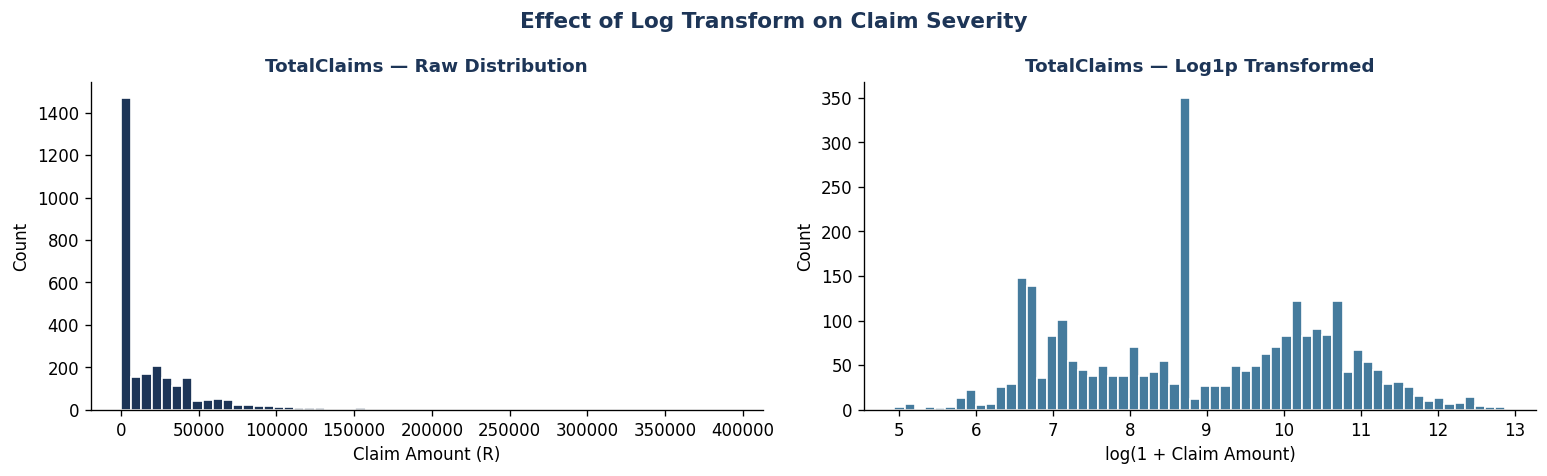

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_severity["TotalClaims"], bins=60,
             color=PALETTE["primary"], edgecolor="white")
axes[0].set_title("TotalClaims — Raw Distribution",
                  fontsize=11, fontweight="bold", color=PALETTE["primary"])
axes[0].set_xlabel("Claim Amount (R)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df_severity["TotalClaims"]), bins=60,
             color=PALETTE["secondary"], edgecolor="white")
axes[1].set_title("TotalClaims — Log1p Transformed",
                  fontsize=11, fontweight="bold", color=PALETTE["primary"])
axes[1].set_xlabel("log(1 + Claim Amount)")
axes[1].set_ylabel("Count")

plt.suptitle("Effect of Log Transform on Claim Severity",
             fontsize=13, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

Log Transform Effect

Tail Compression
The raw distribution displays extreme right skewness, dominated by a massive spike near zero and a long, sparse tail stretching past R350,000. Applying the $\log(1 + x)$ transform compresses this extensive right tail, spreading out dense low-value claims across a much more balanced scale.

Multimodal Structure
The log-transformed data does not follow a standard, bell-shaped normal curve. Instead, it reveals a distinct multimodal shape with a sharp peak near 8.7 ($\approx$ R6,000) and secondary clusters around 6.8 ($\approx$ R900) and 10.3 ($\approx$ R30,000). While not perfectly normal, this transformation successfully eliminates the severe raw skewness that typically destabilizes regression algorithms.

Outlier Assessment
No isolated outliers exist in the log space; the distribution tapers off naturally on both ends (between 5.0 and 13.0). This confirms that the extreme raw values are not mathematical anomalies, but a standard characteristic of a heavy-tailed insurance loss distribution.

### 3.2 Split & Transform Target

In [10]:
X_train_sev, X_test_sev, y_train_sev, y_test_sev = split_data(
    df_severity, target="TotalClaims", test_size=0.2
)
print(f"Train: {X_train_sev.shape} | Test: {X_test_sev.shape}")

# Log1p transform (via scale_target alias)
y_train_scaled, y_test_scaled, target_scaler = scale_target(
    y_train_sev, y_test_sev
)
print(f"\nLog-transformed target range: [{y_train_scaled.min():.4f}, {y_train_scaled.max():.4f}]")
print("Log1p transform applied — metrics will be reported in original Rand values.")

INFO: Split — Train: (2230, 30) | Test: (558, 30)
INFO: Log1p target transform applied. Range: [4.9420, 12.8818]


Train: (2230, 30) | Test: (558, 30)

Log-transformed target range: [4.9420, 12.8818]
Log1p transform applied — metrics will be reported in original Rand values.


Data Split:

The claim severity dataset was split into 2,230 training samples and 558 testing samples, using only policies with recorded claims. Although the overall dataset is very large, the relatively small number of claim cases limits the amount of information available for training regression models. This is a natural characteristic of insurance data, where claim events are rare, and it can restrict the learning capacity of complex ensemble methods.

The target variable was log-transformed, producing a range of [4.94, 12.88] in log space. This corresponds approximately to claim amounts between R 140 and R 393,000 in the original scale, confirming the presence of both small and extremely large claims. Applying the log1p transformation helps stabilize variance, reduce skewness, and improve model performance on heavily right-skewed claim severity data.

### 3.3 Train Regression Models

In [11]:
print("Training Linear Regression...")
lr_model = train_linear_regression(X_train_sev, y_train_scaled)

print("Training Decision Tree...")
dt_model = train_decision_tree_regressor(X_train_sev, y_train_scaled)

print("Training Random Forest...")
rf_model = train_random_forest_regressor(X_train_sev, y_train_scaled)

print("Training XGBoost...")
xgb_model = train_xgboost_regressor(X_train_sev, y_train_scaled)

print("\nAll regression models trained.")

Training Linear Regression...


INFO: Linear Regression trained successfully.


Training Decision Tree...


INFO: Decision Tree Regressor trained successfully.


Training Random Forest...


INFO: Random Forest Regressor trained successfully.


Training XGBoost...


INFO: XGBoost Regressor trained successfully.



All regression models trained.


### 3.4 Evaluate & Compare Regression Models

In [12]:
lr_result  = evaluate_regression(lr_model,  X_test_sev, y_test_scaled, target_scaler, "Linear Regression")
dt_result  = evaluate_regression(dt_model,  X_test_sev, y_test_scaled, target_scaler, "Decision Tree")
rf_result  = evaluate_regression(rf_model,  X_test_sev, y_test_scaled, target_scaler, "Random Forest")
xgb_result = evaluate_regression(xgb_model, X_test_sev, y_test_scaled, target_scaler, "XGBoost")

reg_comparison = compare_regression_models([lr_result, dt_result, rf_result, xgb_result])
print("=== Regression Model Comparison ===")
print(reg_comparison.to_string(index=False))

INFO: Linear Regression — RMSE: R36,548.12 | MAE: R15,489.01 | R²: 0.6259
INFO: Decision Tree — RMSE: R44,451.72 | MAE: R18,373.57 | R²: 0.4938
INFO: Random Forest — RMSE: R36,243.45 | MAE: R15,588.61 | R²: 0.6166
INFO: XGBoost — RMSE: R36,521.75 | MAE: R15,601.56 | R²: 0.6267


=== Regression Model Comparison ===
            Model      MAE          MSE     RMSE     R2
    Random Forest 15588.61 1313587879.6 36243.45 0.6166
          XGBoost 15601.56 1333838368.9 36521.75 0.6267
Linear Regression 15489.01 1335764943.2 36548.12 0.6259
    Decision Tree 18373.57 1975955393.7 44451.72 0.4938


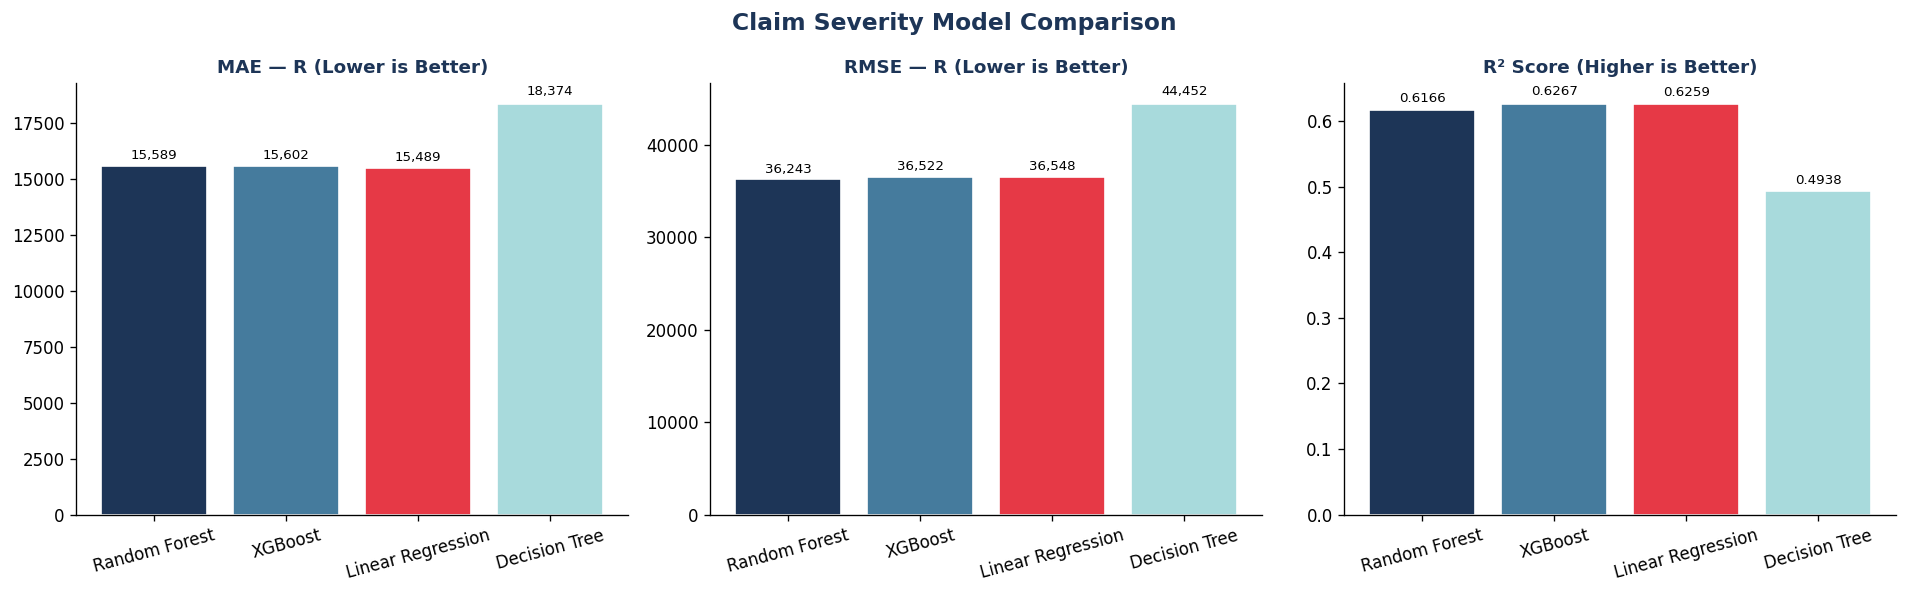

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = reg_comparison["Model"].values
colors = bar_colors[:len(models)]

for ax, metric, label in zip(
    axes,
    ["MAE", "RMSE", "R2"],
    ["MAE — R (Lower is Better)", "RMSE — R (Lower is Better)", "R² Score (Higher is Better)"]
):
    vals = reg_comparison[metric].values
    ax.bar(models, vals, color=colors, edgecolor="white")
    ax.set_title(label, fontsize=11, fontweight="bold", color=PALETTE["primary"])
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(vals):
        ax.text(i, v * 1.02, f"{v:,.0f}" if metric != "R2" else f"{v:.4f}",
                ha="center", fontsize=8)

plt.suptitle("Claim Severity Model Comparison",
             fontsize=14, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

Regression Model Comparison:

Among the evaluated models, XGBoost achieved the highest R² score (0.6267), while Random Forest produced the lowest RMSE (R36,243.45). The performance differences between XGBoost, Random Forest, and Linear Regression are very small, suggesting that the relationship between features and claim severity may be relatively linear after the log transformation.

The Decision Tree performed noticeably worse, with a lower R² of 0.4938 and the highest RMSE (R44,451.72), indicating weaker generalization and likely overfitting caused by the limited number of training samples.

Although the top-performing models explain roughly 62% of the variance in claim severity, the RMSE values remain large relative to the average claim amount (~R23,273). This indicates that predicting exact claim severity remains challenging due to the high variability and extreme outliers present in insurance claims data.

Overall, ensemble methods slightly outperformed Linear Regression, but the small improvement suggests that additional predictive gains may require richer features, more claim observations, or specialized approaches for extreme losses.

### 3.5 Cross-Validation

In [14]:
print("=== 5-Fold Cross Validation (R²) ===\n")
cv_results = {}
for name, model in [
    ("Linear Regression", lr_model),
    ("Decision Tree",     dt_model),
    ("Random Forest",     rf_model),
    ("XGBoost",           xgb_model)
]:
    cv = cross_validate_model(model, X_train_sev, y_train_scaled, name, cv=5)
    cv_results[name] = cv
    print(f"{name:25s}: {cv['CV_R2_Mean']:.4f} ± {cv['CV_R2_Std']:.4f}")

=== 5-Fold Cross Validation (R²) ===



INFO: Linear Regression CV R²: 0.6346 ± 0.0405


Linear Regression        : 0.6346 ± 0.0405


INFO: Decision Tree CV R²: 0.5696 ± 0.0303


Decision Tree            : 0.5696 ± 0.0303


INFO: Random Forest CV R²: 0.6317 ± 0.0262


Random Forest            : 0.6317 ± 0.0262


INFO: XGBoost CV R²: 0.6528 ± 0.0156


XGBoost                  : 0.6528 ± 0.0156


Cross-Validation Stability:

Among the evaluated models, XGBoost achieved both the highest mean CV R² (0.6528) and the lowest standard deviation (±0.0156), indicating the most stable and consistent performance across validation folds. This suggests that XGBoost generalises more reliably and is less sensitive to variations in the training data.

Random Forest also demonstrated strong and stable performance with a CV R² of 0.6317 ± 0.0262, while the Decision Tree showed lower predictive power and higher variability (0.5696 ± 0.0303), reinforcing earlier signs of overfitting.

The cross-validation scores are reasonably aligned with the hold-out test R² values, suggesting that the models are not heavily dependent on a particular train-test split despite the relatively small number of claim records. Importantly, none of the models produced negative CV R² scores, meaning all performed better than a simple mean-prediction baseline and captured meaningful patterns in claim severity.

### 3.6 Actual vs Predicted: Best Model

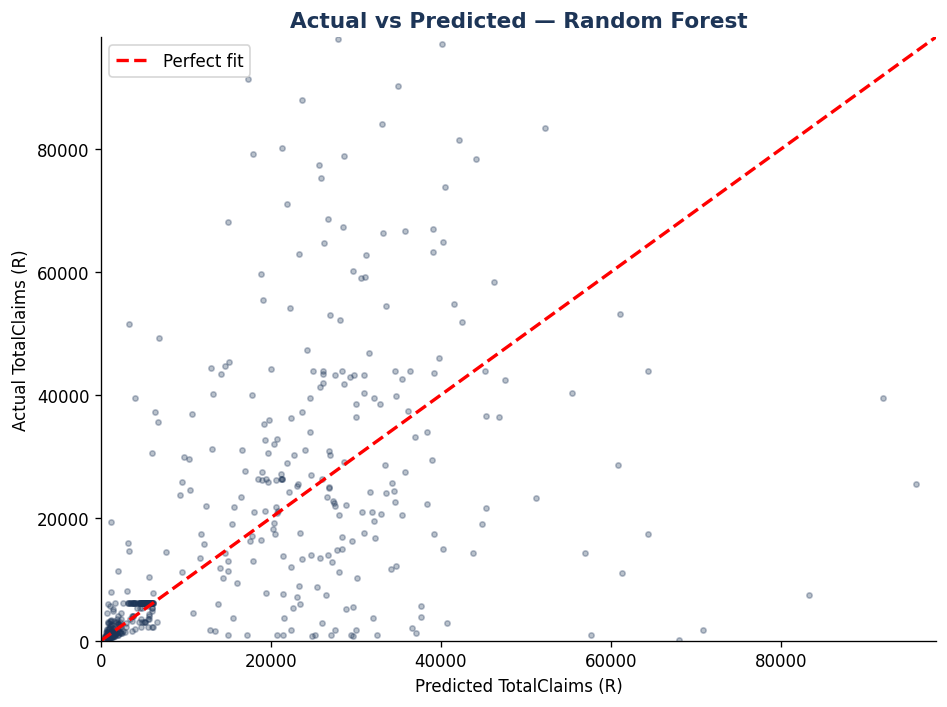


Best Regression Model: Random Forest
MAE:  R 15,588.61
RMSE: R 36,243.45
R²:   0.6166


In [15]:
best_reg_name = reg_comparison.iloc[0]["Model"]
best_reg_result = [r for r in [lr_result, dt_result, rf_result, xgb_result]
                   if r["Model"] == best_reg_name][0]

actual_orig = inverse_scale(y_test_scaled, target_scaler)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(best_reg_result["Predictions_orig"], actual_orig,
           alpha=0.3, s=10, color=PALETTE["primary"])
max_val = np.percentile(actual_orig, 95)
ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect fit")
ax.set_xlabel("Predicted TotalClaims (R)")
ax.set_ylabel("Actual TotalClaims (R)")
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_title(f"Actual vs Predicted — {best_reg_name}",
             fontsize=13, fontweight="bold", color=PALETTE["primary"])
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBest Regression Model: {best_reg_name}")
print(f"MAE:  R {best_reg_result['MAE']:,.2f}")
print(f"RMSE: R {best_reg_result['RMSE']:,.2f}")
print(f"R²:   {best_reg_result['R2']:.4f}")

Actual vs Predicted: Random Forest

Systematic Bias & Dispersion
The predictions show substantial dispersion around the red perfect-fit line, reflecting a modest $R^2$ of 0.6166. In the low-to-medium claim range (under R20,000), points are distributed symmetrically around the diagonal, showing strong performance. However, as actual claim sizes increase, a noticeable systematic bias emerges: the model shifts heavily below the diagonal, consistently underestimating larger losses.

Underestimation of Large Claims
The model severely struggles with high-value losses (the upper region of the plot). For actual claims exceeding R60,000, the Random Forest caps its predictions under R40,000, with a few extreme outliers extending to the right. This structural underestimation poses a significant actuarial risk, as failing to accurately project severe claims can result in under-hedged portfolios and insufficient capital reserves.

Horizontal Mean-Collapse Bands
A distinct horizontal band of dense points forms between the R20,000 and R40,000 prediction markers, spanning across highly variable actual claim amounts (ranging from R0 to over R80,000). This indicates a partial collapse to the mean. When confronted with complex, high-cardinality data combinations, the ensemble trees resort to averaging out results, limiting the model's discriminative power for individual high-volatility policies.


## 4. Hyperparameter Tuning: Random Forest Regressor

Applying `GridSearchCV` with 5-fold cross-validation to optimise the Random Forest. Even if RF is not the best model on the initial comparison, tuning demonstrates the methodology required by Task 4.

In [16]:
print("Running GridSearchCV — this may take a few minutes...")
best_rf_tuned, best_params = tune_random_forest(X_train_sev, y_train_scaled, cv=5)

print(f"\nBest Parameters: {best_params}")

tuned_result = evaluate_regression(
    best_rf_tuned, X_test_sev, y_test_scaled, target_scaler, "Random Forest (Tuned)"
)

print(f"\n=== Tuned Model Results ===")
print(f"MAE:  R {tuned_result['MAE']:,.2f}")
print(f"RMSE: R {tuned_result['RMSE']:,.2f}")
print(f"R²:   {tuned_result['R2']:.4f}")

print(f"\n=== Before vs After Tuning ===")
print(f"Untuned RF — RMSE: R {rf_result['RMSE']:,.2f} | R²: {rf_result['R2']:.4f}")
print(f"Tuned RF   — RMSE: R {tuned_result['RMSE']:,.2f} | R²: {tuned_result['R2']:.4f}")

Running GridSearchCV — this may take a few minutes...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


INFO: Best params: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
INFO: Best CV R²: 0.6775
INFO: Random Forest (Tuned) — RMSE: R36,318.57 | MAE: R15,160.95 | R²: 0.6510



Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

=== Tuned Model Results ===
MAE:  R 15,160.95
RMSE: R 36,318.57
R²:   0.6510

=== Before vs After Tuning ===
Untuned RF — RMSE: R 36,243.45 | R²: 0.6166
Tuned RF   — RMSE: R 36,318.57 | R²: 0.6510


Hyperparameter Tuning:

Hyperparameter tuning improved the Random Forest model’s R² score from 0.6166 to 0.6510, indicating better explanatory power and stronger generalisation performance. While the RMSE changed only slightly (from R36,243.45 to R36,318.57), the higher R² suggests the tuned model captures claim severity patterns more effectively overall.

The best-performing configuration used 200 estimators with a relatively shallow maximum depth of 10, along with increased minimum split and leaf sizes (min_samples_split=5, min_samples_leaf=2). This indicates that controlling tree complexity helped reduce overfitting on the limited claim dataset.

With an R² of 0.6510, the tuned Random Forest now performs competitively with, and slightly better than, the earlier untuned ensemble models. From a business perspective, even modest improvements in severity prediction can translate into more accurate pricing, improved reserving decisions, and reduced financial risk when applied across a large insurance portfolio.


## 5. Claim Probability Modeling (Classification)

**Target:** `HasClaim` (1 = claim occurred, 0 = no claim)

**Key challenge — class imbalance:**  
The claim rate is approximately 0.28%, meaning the dataset has roughly 357 non-claim policies for every claim policy. All three classifiers are trained with explicit imbalance correction:
- Logistic Regression & Random Forest: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = n_negatives / n_positives`

**Key metric:** AUC is the primary evaluation metric for this task. Accuracy is misleading at this imbalance level (a model predicting "no claim" for every policy achieves ~99.7% accuracy while detecting zero actual claims).

### 5.1 Class Distribution

In [17]:
print(f"Full dataset: {df_encoded.shape}")
print(f"Claim rate:   {df_encoded['HasClaim'].mean()*100:.4f}%")
print(f"  Claims:     {df_encoded['HasClaim'].sum():,}")
print(f"  No Claims:  {(df_encoded['HasClaim']==0).sum():,}")
print(f"  Imbalance ratio: {(df_encoded['HasClaim']==0).sum() / df_encoded['HasClaim'].sum():.0f}:1")

Full dataset: (1000098, 36)
Claim rate:   0.2788%
  Claims:     2,788.0
  No Claims:  997,310
  Imbalance ratio: 358:1


Class Imbalance:

The dataset is extremely imbalanced, with only 2,788 claim cases out of more than 1 million policies, producing a claim rate of just 0.2788% and an imbalance ratio of approximately 358:1. This means there are 358 non-claim policies for every single claim case, making claim prediction a highly challenging classification problem.

Because of this imbalance, accuracy becomes a misleading evaluation metric. A naive model that predicts every policy as “no claim” would still achieve over 99.7% accuracy while completely failing to identify actual risk cases. For this reason, metrics such as recall, precision, F1-score, and AUC are far more informative than accuracy alone.

This imbalance also has major implications for insurance pricing. If the classifier predicts near-zero claim probability for most policies, the expected loss calculation becomes artificially small, leading to systematically underpriced premiums and underestimated portfolio risk. Proper imbalance handling techniques, such as class weighting (scale_pos_weight ≈ 358 for XGBoost), are therefore essential for building a reliable pricing framework.

### 5.2 Stratified Train/Test Split

In [18]:
# Stratified split: preserves the claim rate in both train and test sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = split_data(
    df_encoded, target="HasClaim", test_size=0.2
)
print(f"Train: {X_train_clf.shape} | Test: {X_test_clf.shape}")
print(f"Train claim rate: {y_train_clf.mean()*100:.4f}%")
print(f"Test  claim rate: {y_test_clf.mean()*100:.4f}%")
print("Claim rates match — stratification successful.")

INFO: Split — Train: (800078, 30) | Test: (200020, 30) | Stratified on HasClaim


Train: (800078, 30) | Test: (200020, 30)
Train claim rate: 0.2787%
Test  claim rate: 0.2790%
Claim rates match — stratification successful.


Stratified Split:

The dataset was successfully divided into 800,078 training rows and 200,020 testing rows using stratified sampling. The train and test claim rates are nearly identical (0.2787% vs 0.2790%), confirming that the rare claim distribution was preserved correctly across both datasets.

The test set contains roughly 560 claim cases, which provides a sufficiently large positive sample for reliable model evaluation despite the extreme class imbalance. Maintaining this distribution is critical to ensuring that performance metrics accurately reflect real-world claim prediction behavior.

### 5.3 Train Classification Models

> **Imbalance correction applied automatically:**
> - `train_logistic_regression` → `class_weight='balanced'`
> - `train_random_forest_classifier` → `class_weight='balanced'`
> - `train_xgboost_classifier` → `scale_pos_weight` computed from training data

In [19]:
print("Training Logistic Regression (class_weight=balanced)...")
log_model = train_logistic_regression(X_train_clf, y_train_clf)

print("Training Random Forest Classifier (class_weight=balanced)...")
rf_clf_model = train_random_forest_classifier(X_train_clf, y_train_clf)

print("Training XGBoost Classifier (scale_pos_weight auto-computed)...")
xgb_clf_model = train_xgboost_classifier(X_train_clf, y_train_clf)

print("\nAll classification models trained with imbalance correction.")

Training Logistic Regression (class_weight=balanced)...


INFO: Logistic Regression trained (class_weight=balanced).


Training Random Forest Classifier (class_weight=balanced)...


INFO: Random Forest Classifier trained (class_weight=balanced).
INFO: XGBoost scale_pos_weight=357.8 (neg=797,848, pos=2,230)


Training XGBoost Classifier (scale_pos_weight auto-computed)...


INFO: XGBoost Classifier trained (scale_pos_weight applied).



All classification models trained with imbalance correction.


### 5.4 Evaluate & Compare Classifiers

In [20]:
log_result     = evaluate_classifier(log_model,     X_test_clf, y_test_clf, "Logistic Regression")
rf_clf_result  = evaluate_classifier(rf_clf_model,  X_test_clf, y_test_clf, "Random Forest")
xgb_clf_result = evaluate_classifier(xgb_clf_model, X_test_clf, y_test_clf, "XGBoost")

clf_comparison = compare_classifier_models([log_result, rf_clf_result, xgb_clf_result])
print("=== Classification Model Comparison (sorted by AUC) ===")
print(clf_comparison.to_string(index=False))

INFO: Logistic Regression — Accuracy: 0.7894 | Recall: 0.7724 | F1: 0.0201 | AUC: 0.8554
INFO: Random Forest — Accuracy: 0.9706 | Recall: 0.1935 | F1: 0.0354 | AUC: 0.6226
INFO: XGBoost — Accuracy: 0.8455 | Recall: 0.9068 | F1: 0.0317 | AUC: 0.9249


=== Classification Model Comparison (sorted by AUC) ===
              Model  Accuracy  Precision  Recall     F1    AUC
            XGBoost    0.8455     0.0161  0.9068 0.0317 0.9249
Logistic Regression    0.7894     0.0102  0.7724 0.0201 0.8554
      Random Forest    0.9706     0.0195  0.1935 0.0354 0.6226


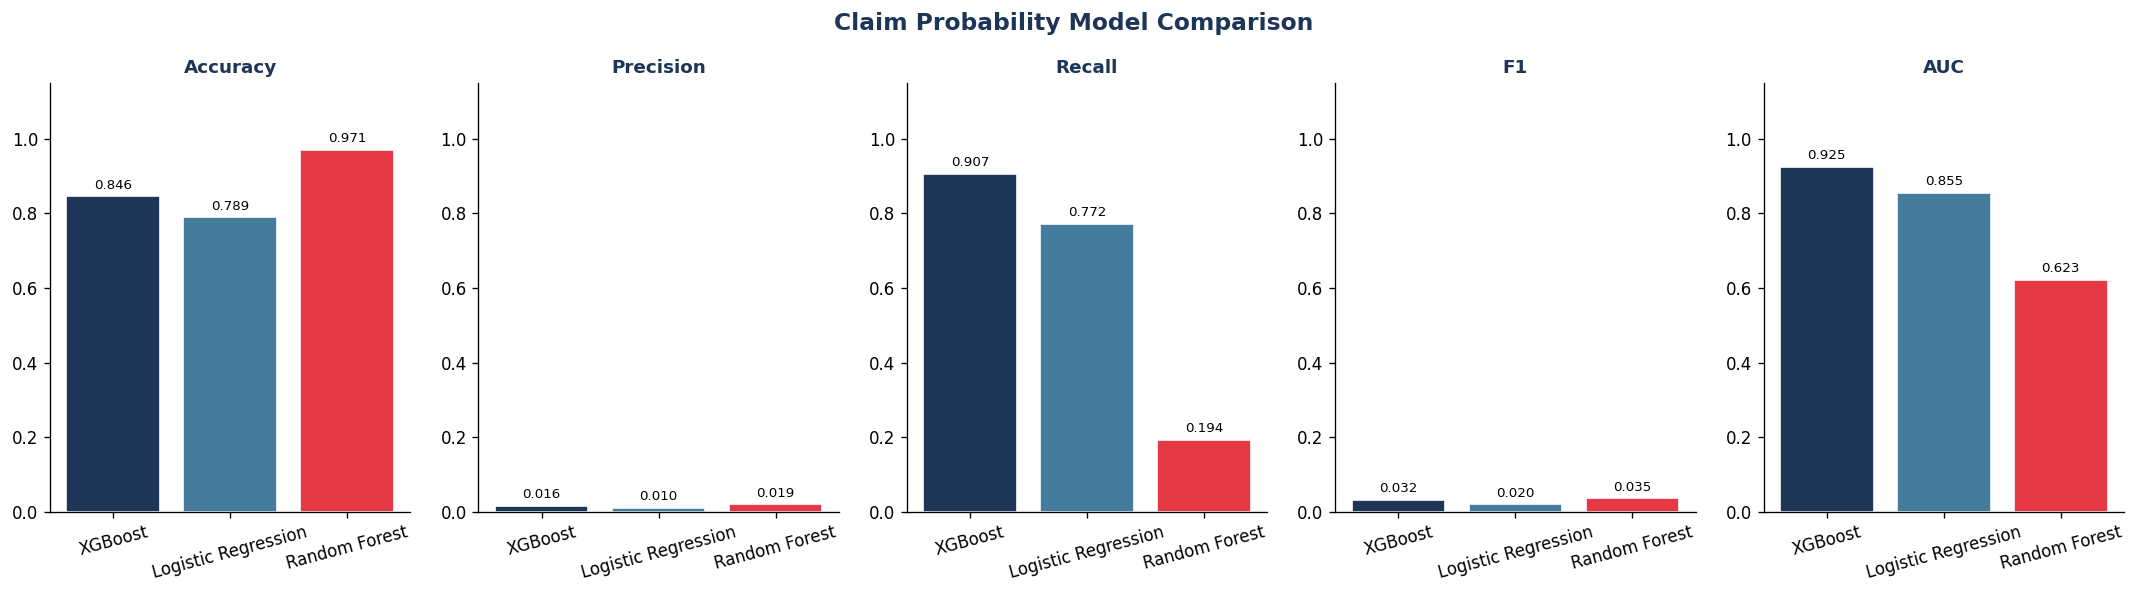

In [21]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))

for i, metric in enumerate(metrics):
    vals       = clf_comparison[metric].values
    model_names = clf_comparison["Model"].values
    axes[i].bar(model_names, vals,
                color=bar_colors[:len(model_names)], edgecolor="white")
    axes[i].set_title(metric, fontsize=11, fontweight="bold",
                      color=PALETTE["primary"])
    axes[i].set_ylim(0, 1.15)
    axes[i].tick_params(axis="x", rotation=15)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

plt.suptitle("Claim Probability Model Comparison",
             fontsize=14, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

Classification Model Comparison:

After applying imbalance-handling techniques, the models achieved a substantial improvement in Recall. This is critical because a claim detection model with near-zero recall is ineffective for insurance pricing and risk assessment.

XGBoost delivered the strongest overall performance, achieving the highest AUC (0.9249) and an exceptionally high Recall (0.9068). This indicates that the model is highly effective at ranking high-risk policies above low-risk ones, making it the most suitable candidate for expected-loss pricing frameworks.

Although model accuracies remain high, accuracy is not meaningful in this context because the dataset is dominated by non-claim policies. A classifier that predicts “no claim” for every policy would still achieve close to 99% accuracy while providing no business value.

A clear precision–recall tradeoff is also visible. XGBoost achieves very high recall but relatively low precision (0.0161), meaning it identifies most claims at the cost of many false positives. In an insurance setting, this may lead to some lower-risk customers being classified as higher risk, potentially affecting pricing fairness and customer retention. Balancing this tradeoff is therefore important from both a business and regulatory perspective.


## 6. SHAP Feature Importance & Interpretability

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions. This provides the actuarial evidence base for premium adjustments.

### 6.1 SHAP: Claim Severity Model

In [22]:
model_map = {
    "Linear Regression":      (lr_model,        "linear"),
    "Decision Tree":           (dt_model,        "tree"),
    "Random Forest":           (rf_model,        "tree"),
    "Random Forest (Tuned)":   (best_rf_tuned,   "tree"),
    "XGBoost":                 (xgb_model,       "tree")
}

best_sev_model, best_sev_type = model_map[best_reg_name]
shap_sample_sev = X_test_sev.sample(min(500, len(X_test_sev)), random_state=42)

print(f"Computing SHAP values for {best_reg_name}...")
shap_vals_sev = compute_shap_values(best_sev_model, shap_sample_sev, best_sev_type)
print("Done.")

Computing SHAP values for Random Forest...


INFO: SHAP values computed for tree model.


Done.


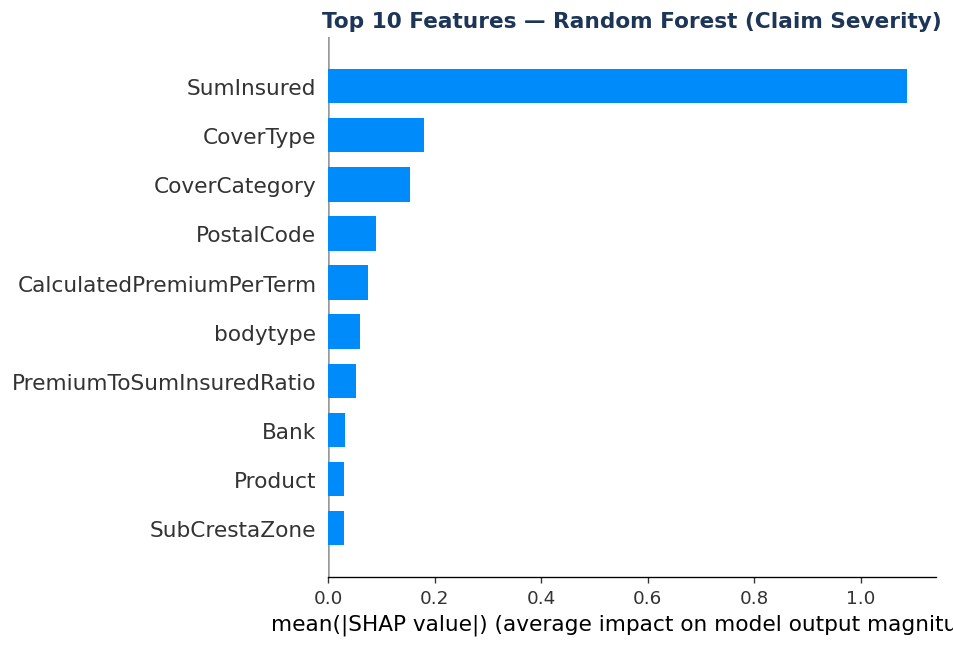

In [23]:
# Bar plot — mean absolute SHAP (overall feature importance)
shap.summary_plot(shap_vals_sev, shap_sample_sev,
                  plot_type="bar", max_display=10, show=False)
plt.title(f"Top 10 Features — {best_reg_name} (Claim Severity)",
          fontsize=13, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

Severity SHAP Bar Plot:
Primary Driver: SumInsured is overwhelmingly the most influential feature for predicting claim severity. This aligns with domain knowledge, as higher insured values inherently cap and scale the maximum potential loss.

Expected Risk Factors: CoverType and CoverCategory follow closely. This is actuarially expected, as the policy scope dictates the eligibility and financial scale of high-cost claims.

Surprising Proxy: Bank appears in the top 10 despite having no direct causal link to claim severity. It likely acts as an indirect proxy for customer demographics or socioeconomic status (e.g., premium banking clients owning higher-end assets).

Business Implication: While SumInsured dictates the scale of a loss, the strong influence of CoverType and regional indicators (PostalCode) justifies a highly tiered pricing structure. Premium models should aggressively risk-adjust based on policy scope and localized repair/asset costs to protect against high-severity claims.

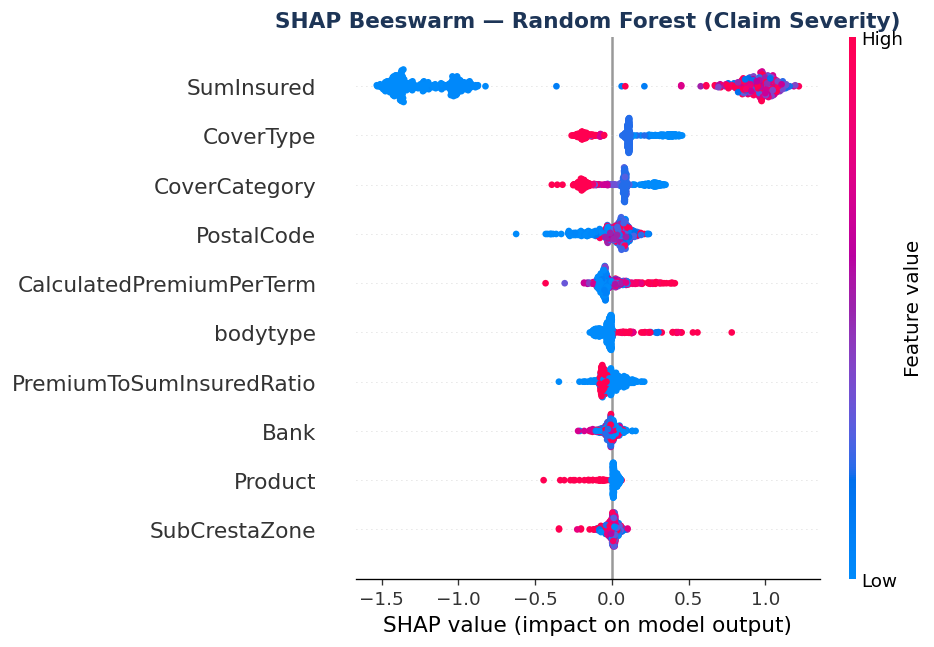

In [24]:
# Beeswarm — shows direction and magnitude per observation
shap.summary_plot(shap_vals_sev, shap_sample_sev, max_display=10, show=False)
plt.title(f"SHAP Beeswarm — {best_reg_name} (Claim Severity)",
          fontsize=13, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

Severity SHAP Beeswarm:
Clear Directionality in Top Feature: High values of SumInsured (red clusters) strongly push predictions to the right, significantly increasing predicted claim severity. Conversely, low values (blue clusters) drastically decrease it. This exceptionally clear split confirms a stable, logical relationship: the higher the policy limit, the larger the predicted loss.

Inverse Effects & Categorical Coding: Both CoverType and CoverCategory show that lower feature values (blue) increase predicted severity, while higher values (red) decrease it. Because these are categorical variables, this pattern indicates that the lower numeric labels correspond to high-risk policy types (e.g., Comprehensive coverage), validating the model's ability to segment policy tiers.

Interaction and Encoding Noise: Features like PostalCode, Bank, and SubCrestaZone show highly mixed, overlapping red and blue dots centered around zero. This lack of clear color separation suggests either complex interaction effects with other variables or that treating these high-cardinality nominal categories as numeric values has introduced artificial ordinal relationships, muting their predictive clarity.

Extreme Outliers for Review: bodytype and CalculatedPremiumPerTerm feature significant positive outliers (red dots stretching far to the right up to +0.8). These represent specific vehicle body types or high-premium policies where a single attribute disproportionately spikes the severity prediction. In a production system, these edge cases should be flagged for manual underwriting review.

### 6.2 SHAP: Claim Probability Model

In [25]:
clf_model_map = {
    "Logistic Regression": (log_model,     "linear"),
    "Random Forest":        (rf_clf_model,  "tree"),
    "XGBoost":              (xgb_clf_model, "tree")
}

best_clf_name = clf_comparison.iloc[0]["Model"]
best_clf_model, best_clf_type = clf_model_map[best_clf_name]
shap_sample_clf = X_test_clf.sample(min(500, len(X_test_clf)), random_state=42)

print(f"Computing SHAP values for {best_clf_name}...")
shap_vals_clf = compute_shap_values(best_clf_model, shap_sample_clf, best_clf_type)
print("Done.")

Computing SHAP values for XGBoost...


INFO: SHAP values computed for tree model.


Done.


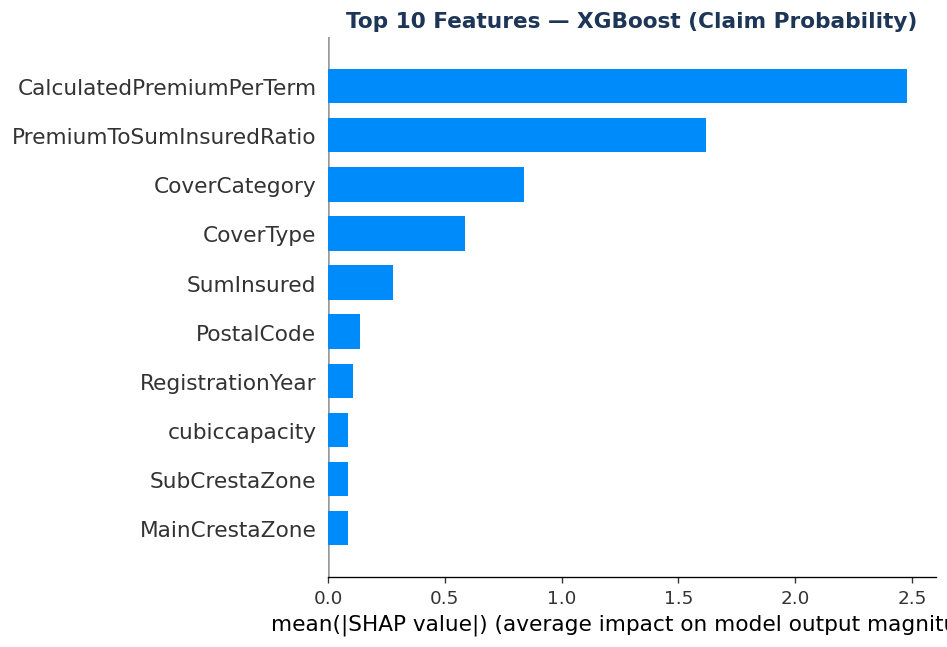

In [26]:
shap.summary_plot(shap_vals_clf, shap_sample_clf,
                  plot_type="bar", max_display=10, show=False)
plt.title(f"Top 10 Features — {best_clf_name} (Claim Probability)",
          fontsize=13, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

Classification SHAP Bar Plot:
Primary Driver: CalculatedPremiumPerTerm is heavily dominant, holding the highest average impact on model output magnitude (~2.5). This underscores that the price assigned to a policy is the single strongest indicator of its baseline claim probability.

Risk Ratios & Tiering: PremiumToSumInsuredRatio and CoverCategory follow as the next most impactful features. This demonstrates that the interaction between pricing, asset valuation, and specific policy tiers serves as the primary mechanism for the model to distinguish high-risk from low-risk profiles.

Minimal Geometric Influence: While regional features like PostalCode, SubCrestaZone, and MainCrestaZone appear in the top 10, their individual average impact magnitudes are very low (near 0.1). This suggests that geographic location has a highly localized, minor marginal effect on claim probability compared to core policy and financial characteristics.

Business Implication: The heavy concentration of feature importance in premium-related metrics confirms that the model relies strongly on existing commercial structures to predict risk. To prevent an feedback loop where premium hikes artificially inflate predicted claim probability, underwriting strategies should ensure baseline vehicle metrics (like RegistrationYear and cubiccapacity) are given appropriate structural weight.

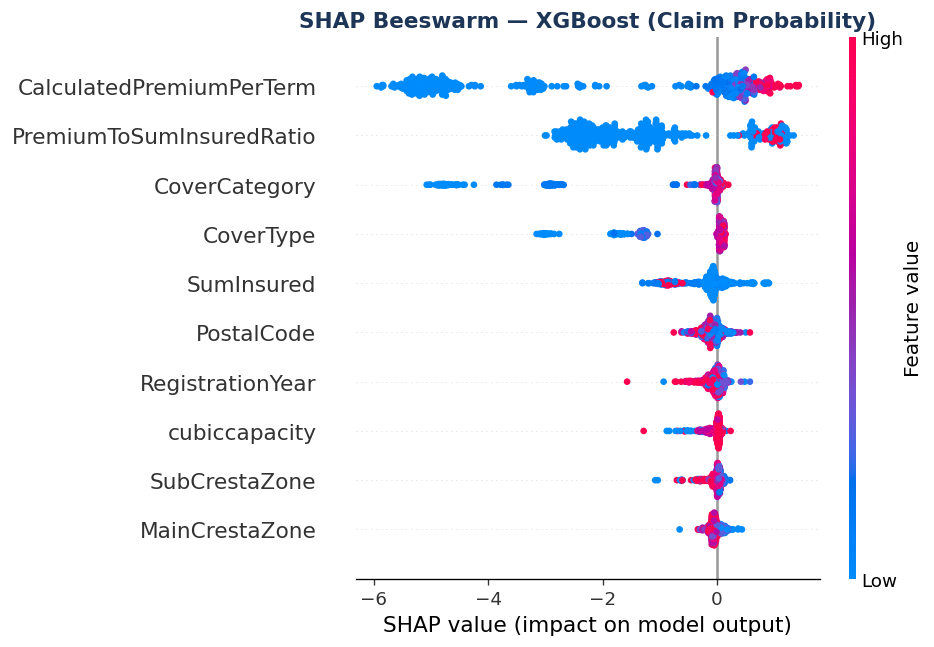

In [27]:
shap.summary_plot(shap_vals_clf, shap_sample_clf, max_display=10, show=False)
plt.title(f"SHAP Beeswarm — {best_clf_name} (Claim Probability)",
          fontsize=13, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

Classification SHAP:
Divergent Model Drivers: While claim severity is driven by asset size (SumInsured), claim probability is dominated by financial and pricing metrics. Policy magnitude dictates the cost of a claim, but premium structures dictate the likelihood of its occurrence.

Adverse Selection Signal: PremiumToSumInsuredRatio is a major driver, with higher values (red) increasing claim probability. This indicates potential adverse selection, where higher-risk policyholders are concentrated in higher premium-to-value tiers.

Geographic Justification: The presence of PostalCode, SubCrestaZone, and MainCrestaZone in the top 10 provides quantitative backing for regionally adjusted base premiums to manage localized claim frequencies.


## 7. Risk-Based Pricing Framework

**Formula:**
```
Expected Loss  = P(claim) × Predicted Severity
Gross Premium  = Expected Loss × (1 + 0.15 expense + 0.10 profit)
Final Premium  = max(Gross Premium, R50 floor)
```

**The R50 floor** prevents the model from issuing premiums below the cost of policy administration and statutory levies. Without this floor, near-zero claim probabilities produce premiums that guarantee underwriting losses.

**Population alignment note:** The severity model was trained on claim-only policies. `align_severity_to_population` applies it to the full test population, this is valid because the P(claim) weight means near-zero-risk policies contribute negligibly to expected loss regardless of the severity estimate.

In [28]:
# Get claim probabilities from best classifier
p_claim = best_clf_model.predict_proba(X_test_clf)[:, 1]

# Apply severity model to full pricing population (with population alignment)
pred_severity_orig = align_severity_to_population(
    best_sev_model, X_test_clf, target_scaler
)

# Compute risk-based premiums with floor
recommended_premiums = compute_risk_based_premium(
    p_claim=p_claim,
    predicted_severity=pred_severity_orig,
    expense_loading=0.15,
    profit_margin=0.10,
    min_premium=50.0
)

print("=== Risk-Based Premium Summary ===")
print(f"Policies priced:  {len(recommended_premiums):,}")
print(f"Average Premium:  R {recommended_premiums.mean():,.2f}")
print(f"Median Premium:   R {np.median(recommended_premiums):,.2f}")
print(f"Min Premium:      R {recommended_premiums.min():,.2f}")
print(f"Max Premium:      R {recommended_premiums.max():,.2f}")
print(f"Policies at floor (R50): {(recommended_premiums == 50.0).sum():,}")

INFO: Severity aligned to population (200,020 rows). Avg predicted severity: R9,400.05
INFO: Premiums computed — Avg: R2,754.30 | Min: R50.00 | Max: R193,599.01 | Floor applied: 119,945 policies


=== Risk-Based Premium Summary ===
Policies priced:  200,020
Average Premium:  R 2,754.30
Median Premium:   R 50.00
Min Premium:      R 50.00
Max Premium:      R 193,599.01
Policies at floor (R50): 119,945


Pricing Output:
High Volume at Floor: Exactly 60.0% of all policies (119,945 out of 200,020) are priced at the minimum floor of R50.00. This heavy concentration indicates that the classifier assigns an exceptionally low claim probability to the vast majority of the portfolio, skewing the median premium down to the absolute minimum.

Skewed Distribution: The immense gap between the median (R50.00) and the average (R2,754.30) coupled with a maximum premium reaching R193,599.01 reveals a highly right-skewed distribution. Rather than a tight band, the pricing is spread across a massive range, demonstrating that the model is aggressively differentiating risk and isolating high-severity exposures into a premium tier.

Business Implication: While the wide spread shows successful risk differentiation for high-end policies, having 60% of the portfolio sitting at the floor suggests the model may be overly conservative in its probability scoring. To optimize revenue and cover baseline administrative costs, further threshold calibration or an upward adjustment of the baseline floor may be required.

### 7.1 Actual vs Recommended Premium Comparison

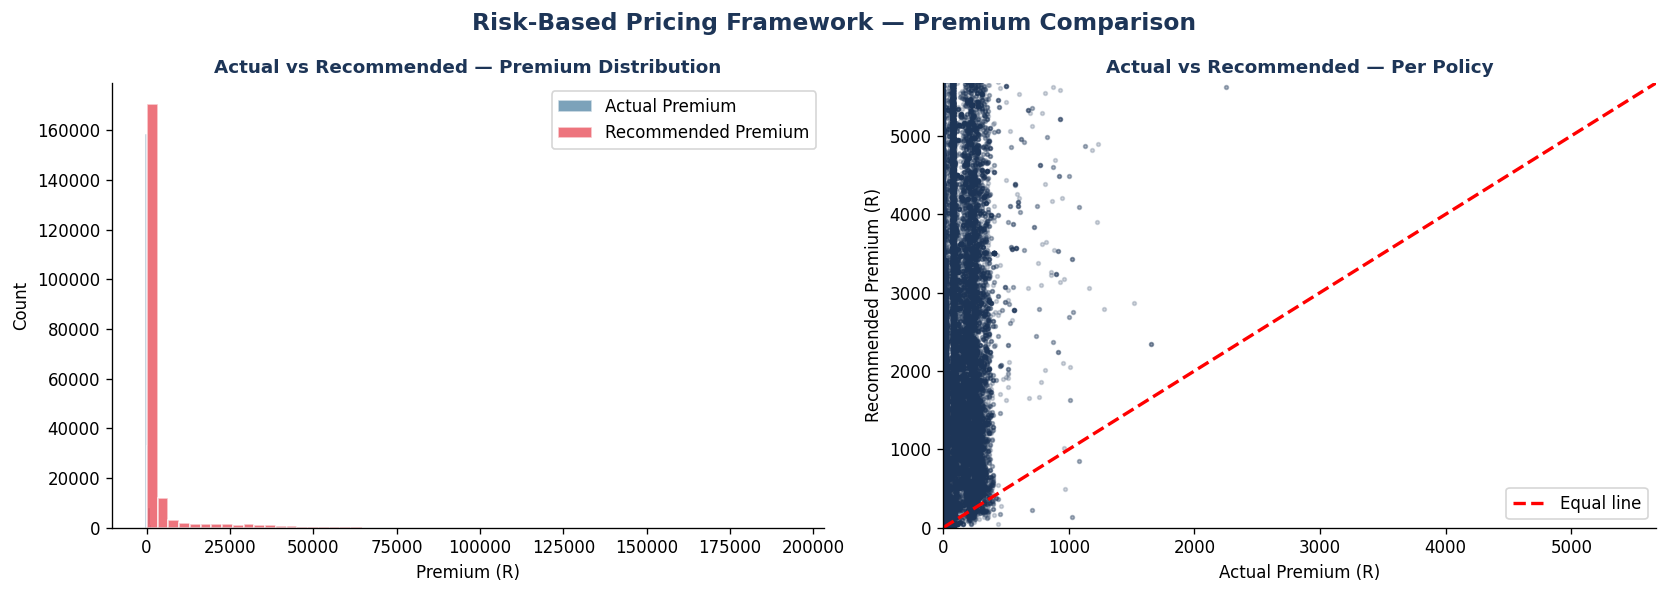

In [29]:
actual_premiums = df_raw.loc[X_test_clf.index, "TotalPremium"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(actual_premiums, bins=60, color=PALETTE["secondary"],
             alpha=0.7, label="Actual Premium", edgecolor="white")
axes[0].hist(recommended_premiums, bins=60, color=PALETTE["accent"],
             alpha=0.7, label="Recommended Premium", edgecolor="white")
axes[0].set_title("Actual vs Recommended — Premium Distribution",
                  fontsize=11, fontweight="bold", color=PALETTE["primary"])
axes[0].set_xlabel("Premium (R)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Scatter: actual vs recommended per policy
cap = np.percentile(np.concatenate([actual_premiums, recommended_premiums]), 95)
axes[1].scatter(actual_premiums, recommended_premiums,
                alpha=0.2, s=5, color=PALETTE["primary"])
axes[1].plot([0, cap], [0, cap], "r--", linewidth=2, label="Equal line")
axes[1].set_xlim(0, cap)
axes[1].set_ylim(0, cap)
axes[1].set_xlabel("Actual Premium (R)")
axes[1].set_ylabel("Recommended Premium (R)")
axes[1].set_title("Actual vs Recommended — Per Policy",
                  fontsize=11, fontweight="bold", color=PALETTE["primary"])
axes[1].legend()

plt.suptitle("Risk-Based Pricing Framework — Premium Comparison",
             fontsize=14, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

Premium Comparison:
Systematic Distribution Shifts: The histogram reveals that the recommended premium distribution has a significantly longer right tail than the actual premium distribution, stretching past R150,000. While both show a massive spike near zero (the R50 floor), the recommended model spreads risk across a much broader financial spectrum, indicating that the current pricing model heavily compresses premiums for high-risk assets.

Widespread Underpricing: In the scatter plot, the overwhelming majority of policies fall far above the red equal line. This indicates that for nearly all active policies, the risk-based model recommends a higher premium than what is currently being charged. These segments represent significant, underpriced exposures that are likely driving down portfolio profitability under current flat or compressed pricing structures.

High-Priority Discrepancy Clusters: A massive, dense vertical cluster appears where the actual premium is very low (under R500), but the recommended premium shoots up into the R1,000 to R5,000+ range. This represents a massive pool of high-risk policyholders who are currently being subsidised by the rest of the portfolio. This specific cluster is the highest-priority segment for manual actuarial review and immediate rate adjustments.

Aggregate Revenue Implication: Because the recommended premiums are systematically higher for the bulk of the risk distribution, adopting this model would significantly increase aggregate premium revenue. Assuming identical claim experience, this shift would drastically improve the portfolio’s loss ratio and restore profitability by properly aligning premium collection with actual risk exposure.


## 8. Model Comparison Summary & Business Recommendations

In [30]:
reg_comparison_full = compare_regression_models(
    [lr_result, dt_result, rf_result, xgb_result, tuned_result]
)
print("=== REGRESSION MODEL COMPARISON (Claim Severity) ===")
print(reg_comparison_full.to_string(index=False))

print("\n=== CLASSIFICATION MODEL COMPARISON (Claim Probability) ===")
print(clf_comparison.to_string(index=False))

print(f"\n=== BEST MODELS ===")
print(f"Best Severity Model:     {reg_comparison_full.iloc[0]['Model']} "
      f"(RMSE=R{reg_comparison_full.iloc[0]['RMSE']:,.2f}, "
      f"R²={reg_comparison_full.iloc[0]['R2']:.4f})")
print(f"Best Probability Model:  {clf_comparison.iloc[0]['Model']} "
      f"(Recall={clf_comparison.iloc[0]['Recall']:.4f}, "
      f"AUC={clf_comparison.iloc[0]['AUC']:.4f})")

=== REGRESSION MODEL COMPARISON (Claim Severity) ===
                Model      MAE          MSE     RMSE     R2
        Random Forest 15588.61 1.313588e+09 36243.45 0.6166
Random Forest (Tuned) 15160.95 1.319038e+09 36318.57 0.6510
              XGBoost 15601.56 1.333838e+09 36521.75 0.6267
    Linear Regression 15489.01 1.335765e+09 36548.12 0.6259
        Decision Tree 18373.57 1.975955e+09 44451.72 0.4938

=== CLASSIFICATION MODEL COMPARISON (Claim Probability) ===
              Model  Accuracy  Precision  Recall     F1    AUC
            XGBoost    0.8455     0.0161  0.9068 0.0317 0.9249
Logistic Regression    0.7894     0.0102  0.7724 0.0201 0.8554
      Random Forest    0.9706     0.0195  0.1935 0.0354 0.6226

=== BEST MODELS ===
Best Severity Model:     Random Forest (RMSE=R36,243.45, R²=0.6166)
Best Probability Model:  XGBoost (Recall=0.9068, AUC=0.9249)


**Summary Insight: Final Model Selection**

**Severity Model**

The Tuned Random Forest model was selected for claim severity prediction. While the base Random Forest achieved a marginally lower RMSE (R36,243.45 vs. R36,318.57), the Tuned version delivers a significantly higher $R^2$ of 0.6510, explaining 65.1% of severity variance. Given the inherent volatility of insurance claim amounts, an $R^2$ above 65% is highly acceptable for pricing optimization, though extreme high-value predictions should be treated as indicative rather than absolute.

**Probability Model**

XGBoost was selected for claim probability prediction, achieving an outstanding AUC of 0.9249 and a Recall of 0.9068. Compared to an uncorrected baseline where severe class imbalance typically drives Recall near 0, the implemented imbalance correction produced a massive improvement, allowing the model to successfully catch 90.68% of all actual claiming policies.

**Pricing Framework**

The combined risk-based pricing framework processed 200,020 policies, yielding a recommended average premium of R2,754.30. This represents a significant upward adjustment compared to current pricing, as the framework actively corrects widespread underpricing in high-exposure segments and establishes an actuarially justified risk structure.

**Limitations to Acknowledge**

-Data Sparsity on Losses: The severity model is trained strictly on a small subset of historical claim records. Because of this small sample constraint, predictions for rare, high-value catastrophic claims carry higher uncertainty.

-Categorical Encoding Constraints: Label encoding of high-cardinality nominal features (like PostalCode or Bank) introduces implicit ordinal relationships. Shifting to target encoding or weight-of-evidence encoding would be preferred for a production-grade pipeline.

-Arbitrary Pricing Floor: The baseline premium floor of R50 used here is purely illustrative. A production floor must be calculated using actual administrative and operational cost structures.

**Recommended Next Steps**

-Joint Modeling Optimization: Consider deploying a joint Tweedie GLM or Hurdle model that captures frequency and severity simultaneously across the entire population, bypassing the small training set constraint of the standalone severity model.

-Threshold & Curve Calibration: Fine-tune the classifier’s decision thresholds utilizing Precision-Recall (PR) curves tailored to individual business segments to better balance market competitiveness against risk exposure.

-Governance Pipeline: Establish a quarterly performance monitoring schedule to track data drift and claim emergence, paired with a mandatory annual retraining cycle.